Run IMSTE on MNIST, Fashion-MNIST, and Kuzushiji-MNIST. For each dataset, the gallery first shows a grid of sample images with one column per class and a configurable number of rows. It standardizes a stratified sample and fits IMSTE directly to the flattened image features. The summary reports the sample and feature counts.

Remote datasets download on first use and are cached. Set `MAX_SAMPLES` or `N_EPOCHS` lower for a faster run. Graph construction uses exact Euclidean distances; `N_MSTS` controls the number of edge-disjoint trees.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "high_dim_mst_gallery.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))
    sys.path.insert(0, str(repo_root))

Loading MNIST (28×28) ...
  2,000 samples × 784 features; 10 classes
Loading Fashion-MNIST (28×28) ...
  2,000 samples × 784 features; 10 classes
Loading Kuzushiji-MNIST (28×28) ...
  2,000 samples × 784 features; 10 classes


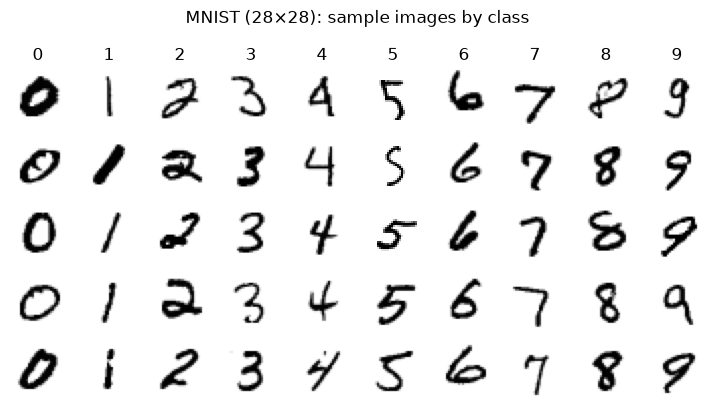

Fitting MNIST (28×28) on mps ...
  pipeline completed in 11.59 seconds
  standardized IMSTE input: 2,000 samples × 784 features


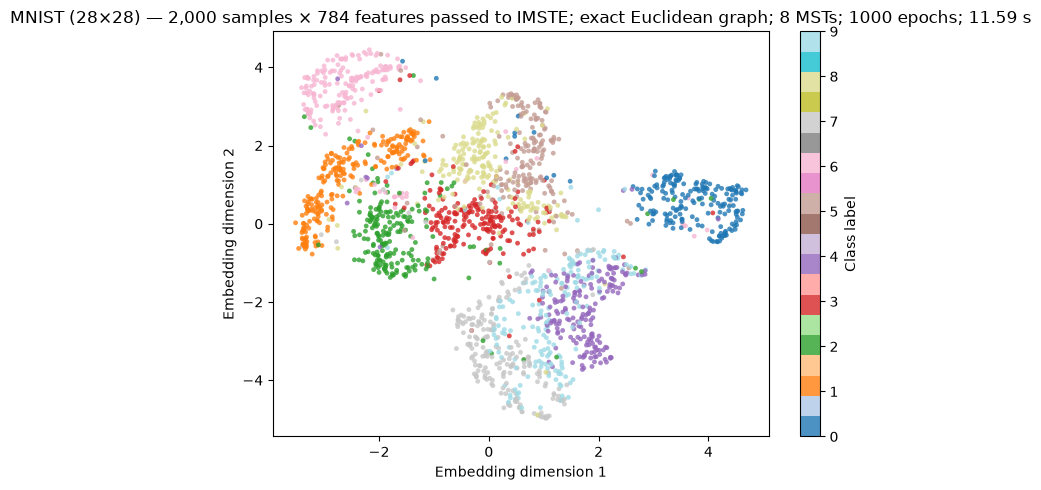

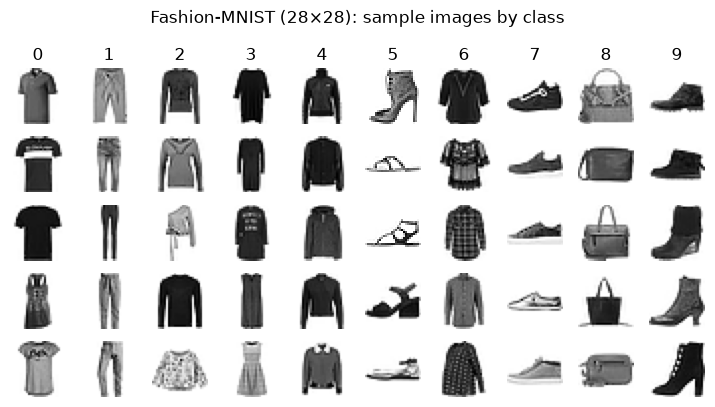

Fitting Fashion-MNIST (28×28) on mps ...
  pipeline completed in 9.13 seconds
  standardized IMSTE input: 2,000 samples × 784 features


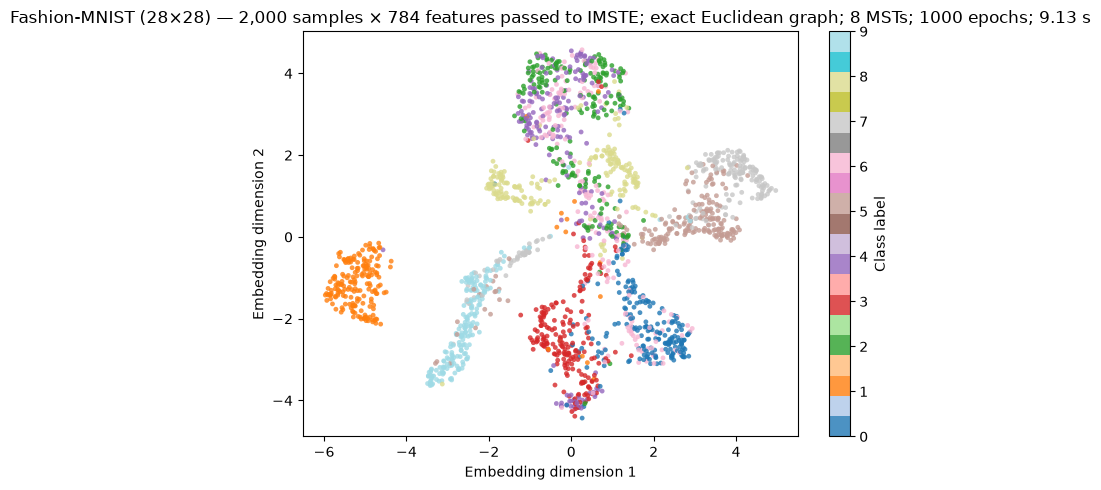

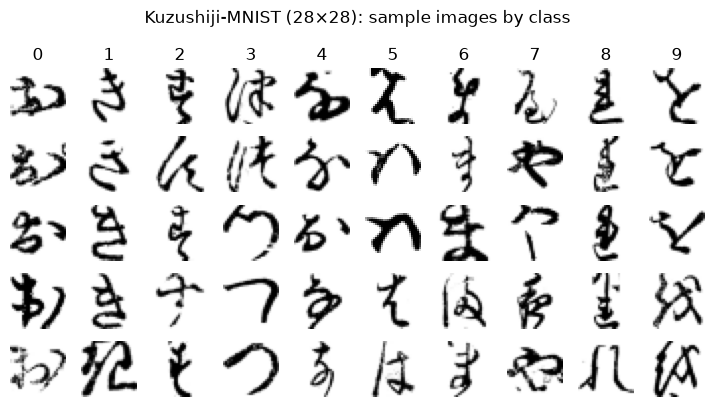

Fitting Kuzushiji-MNIST (28×28) on mps ...
  pipeline completed in 7.18 seconds
  standardized IMSTE input: 2,000 samples × 784 features


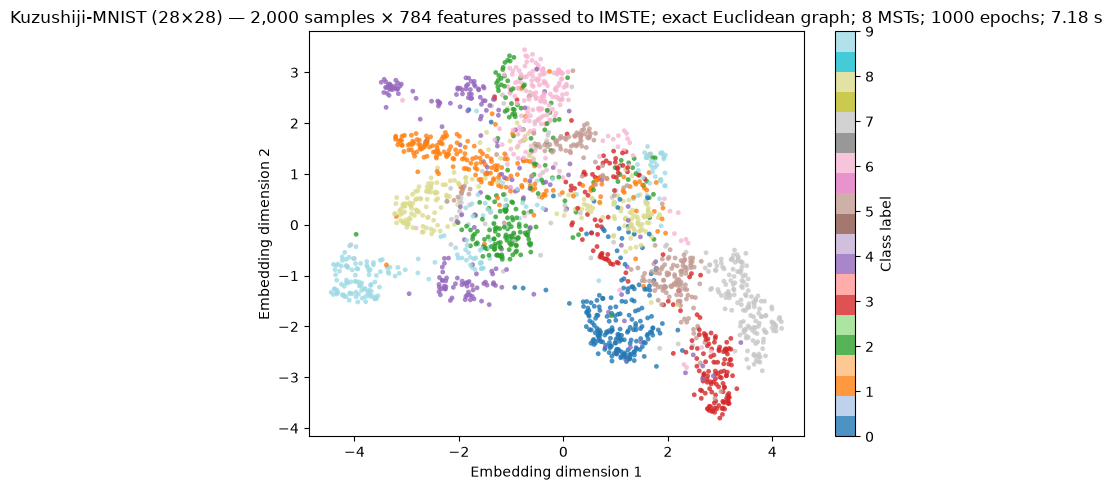

,dataset,samples,input_features,features,classes,n_msts,n_epochs,negative_ratio,lambda_rep,repulsion_type,unique_graph_edges,seconds,device
0,MNIST (28×28),2000,784,784,10,8,1000,5,0.5,bernoulli,15992,11.591606,mps
1,Fashion-MNIST (28×28),2000,784,784,10,8,1000,5,0.5,bernoulli,15992,9.127170,mps
2,Kuzushiji-MNIST (28×28),2000,784,784,10,8,1000,5,0.5,bernoulli,15992,7.181775,mps


In [2]:
from high_dim_mst_gallery import run_high_dim_mst_gallery

# Dataset
MAX_SAMPLES = 2000
SAMPLE_PLOT_ROWS = 5

#----
# Embedding
NEGATIVE_RATIO = 5
LAMBDA_REP = .5
REPULSION_TYPE = "bernoulli" #"bernoulli" or "inverse_distance"

#----
# Graph construction
N_MSTS = 8

gallery = run_high_dim_mst_gallery(
    max_samples=MAX_SAMPLES,
    sample_plot_rows=SAMPLE_PLOT_ROWS,
    negative_ratio=NEGATIVE_RATIO,
    lambda_rep=LAMBDA_REP,
    repulsion_type=REPULSION_TYPE,
    n_msts=N_MSTS,
)
gallery["summary"]
